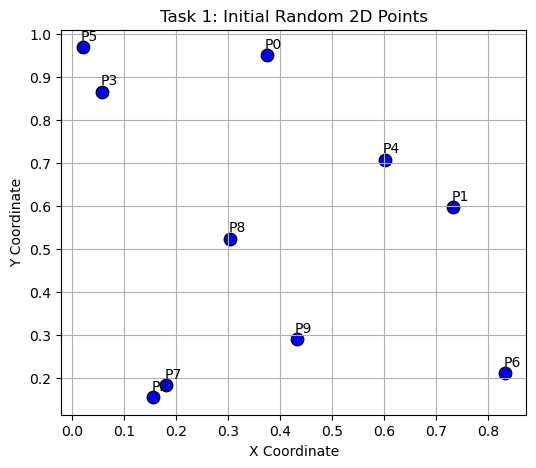

--- TASK 2 SHAPES ---
Shape (a) Coordinate differences:  (10, 10, 2)
Shape (b) Squared differences:     (10, 10, 2)
Shape (c) Summed sq. distances:   (10, 10)

--- TASK 3 VERIFICATION ---
Diagonal of Distance Matrix: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

--- TASK 4 NEIGHBOR MATRIX ---
Argsort Indices (Row i shows sorted neighbors):
 [[0 3 4 5 8 1 9 7 2 6]
 [1 4 6 9 8 0 7 3 2 5]
 [2 7 9 8 6 4 3 1 0 5]
 [3 5 0 8 4 9 7 2 1 6]
 [4 1 0 8 9 6 3 5 7 2]
 [5 3 0 8 4 9 1 7 2 6]
 [6 1 9 4 8 7 2 0 3 5]
 [7 2 9 8 6 4 1 3 0 5]
 [8 9 4 7 2 3 0 1 5 6]
 [9 8 7 2 6 1 4 0 3 5]]

Argpartition Indices (K=2 nearest + self, un-sorted):
 [[3 0 4]
 [1 4 6]
 [2 7 9]
 [3 5 0]
 [1 4 0]
 [5 3 0]
 [1 9 6]
 [7 2 9]
 [8 9 4]
 [8 7 9]]


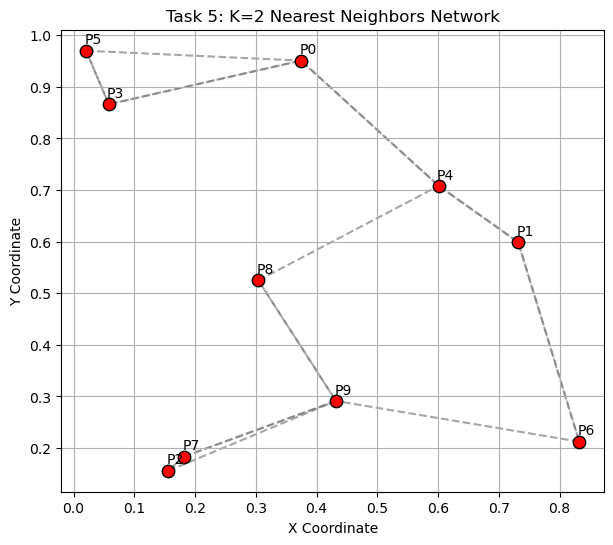


--- TASK 6 BENCHMARKING (%timeit) ---

--- Timing N = 100 ---
Vectorized Version:
726 μs ± 88.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Looped Version:
105 ms ± 10.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

--- Timing N = 1000 ---
Vectorized Version:
107 ms ± 16.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Looped Version:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Set seed for reproducibility across all tasks
np.random.seed(42)

# ==============================================================================
# TASK 1: Data Generation
# ==============================================================================
# Generate a (10, 2) array of random points
X = np.random.rand(10, 2)

# Scatter plot of points
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], color='blue', edgecolors='k', s=80)
for i, (x, y) in enumerate(X):
    plt.annotate(f"P{i}", (x, y), textcoords="offset points", xytext=(5, 5), ha='center')

plt.title("Task 1: Initial Random 2D Points")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

# ==============================================================================
# TASK 2: Pairwise Squared Distances
# ==============================================================================
# Single-line vectorized computation using broadcasting
dist_sq_single = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=-1)

# Three-step breakdown with shape outputs:
# (a) Coordinate differences
diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]

# (b) Squared differences
sq_diff = diff ** 2

# (c) Summed squared distances
dist_sq = np.sum(sq_diff, axis=-1)

print("--- TASK 2 SHAPES ---")
print("Shape (a) Coordinate differences: ", diff.shape)       # (10, 10, 2)
print("Shape (b) Squared differences:    ", sq_diff.shape)      # (10, 10, 2)
print("Shape (c) Summed sq. distances:  ", dist_sq.shape)     # (10, 10)

# ==============================================================================
# TASK 3: Verification
# ==============================================================================
diagonal_vals = np.diag(dist_sq)

print("\n--- TASK 3 VERIFICATION ---")
print("Diagonal of Distance Matrix:", diagonal_vals)

# Explanation: The diagonal element dist_sq[i, i] corresponds to the distance 
# between point P_i and itself. Since (x_i - x_i)^2 + (y_i - y_i)^2 = 0, 
# the self-distance is always zero.

# ==============================================================================
# TASK 4: Sorting for Neighbors
# ==============================================================================
# (a) Full sort via argsort
nearest_argsort = np.argsort(dist_sq, axis=1)

# (b) K = 2 Nearest Neighbors via argpartition
K = 2
nearest_partition = np.argpartition(dist_sq, K + 1, axis=1)[:, :K + 1]

print("\n--- TASK 4 NEIGHBOR MATRIX ---")
print("Argsort Indices (Row i shows sorted neighbors):\n", nearest_argsort)
print("\nArgpartition Indices (K=2 nearest + self, un-sorted):\n", nearest_partition)

# Explanations:
# 4(a): The first column is always 0, 1, 2, ..., 9 because the smallest distance 
#       in row i is 0 (distance to itself). Thus, index i ranks 1st in row i.
# 4(b): argpartition runs in O(N) linear time via quickselect, whereas argsort 
#       runs in O(N log N). When only K neighbors are needed, full sorting is unnecessary.

# ==============================================================================
# TASK 5: Visualization
# ==============================================================================
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], color='red', edgecolors='k', zorder=3, s=80)

for i in range(X.shape[0]):
    # Exclude index 0 (self) and take the next K=2 nearest indices
    neighbors = nearest_argsort[i, 1:K + 1]
    for j in neighbors:
        plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], color='gray', linestyle='--', alpha=0.7, zorder=1)
    plt.annotate(f"P{i}", (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(5, 5), ha='center')

plt.title("Task 5: K=2 Nearest Neighbors Network")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

# Explanation: Some points have >2 connections because neighbor relationships are 
# asymmetric. Point A may have Point B as a neighbor, but Point B's closest 
# neighbors might be Points C and D. Central points naturally attract incoming edges.

# ==============================================================================
# TASK 6: Performance Comparison
# ==============================================================================
# Vectorized Implementation
def compute_vectorized(data, k=2):
    dists = np.sum((data[:, np.newaxis, :] - data[np.newaxis, :, :]) ** 2, axis=-1)
    return np.argpartition(dists, k + 1, axis=1)[:, :k + 1]

# Loop-based Implementation
def compute_looped(data, k=2):
    n = data.shape[0]
    result = np.zeros((n, k + 1), dtype=int)
    for i in range(n):
        dists = np.zeros(n)
        for j in range(n):
            dists[j] = np.sum((data[i] - data[j]) ** 2)
        result[i] = np.argpartition(dists, k + 1)[:k + 1]
    return result

print("\n--- TASK 6 BENCHMARKING (%timeit) ---")

for N in [100, 1000, 5000]:
    X_bench = np.random.rand(N, 2)
    print(f"\n--- Timing N = {N} ---")
    
    print("Vectorized Version:")
    %timeit compute_vectorized(X_bench)
    
    if N <= 1000:  # Skip looped 5000 run if too slow, or run to compare
        print("Looped Version:")
        %timeit compute_looped(X_bench)

# Discussion:
# Vectorization is faster because NumPy executes matrix operations in optimized C 
# binaries using continuous memory blocks (SIMD).
# The code is scale/dimension invariant because np.newaxis broadcasts dynamically 
# and axis=-1 automatically aggregates over the final feature dimension (D).

# ==============================================================================
# TASK 7 : Scikit-Learn Comparison
# ==============================================================================
N_bonus = 1000
X_bonus = np.random.rand(N_bonus, 2)

print("\n--- TASK 7  BENCHMARK (N=1000) ---")

print("NumPy Vectorized Brute Force:")
%timeit compute_vectorized(X_bonus, k=2)

print("Scikit-Learn KD-Tree:")
%timeit NearestNeighbors(n_neighbors=3, algorithm='kd_tree').fit(X_bonus).kneighbors(X_bonus)

